In [1]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# _________________________________________________ Test Stage _____________________________________________
# _________________________________________Load Feature Extraction Vectores ________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [2]:
# load Feature Extraction Vectors
import numpy as np
import pandas as pd

# Set feature_type to one of: 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'
feature_type = 'yolo'

features_array = None

# التعديل هنا لتحميل الملفات من المجلد mul_Features الناتج عن كود الاستخراج الجديد
if feature_type == 'all':
    df = pd.read_csv('Bin_Features/combined_all_features_array.csv')
    print("Loaded ALL features (ML + DL).")
elif feature_type == 'ml':
    df = pd.read_csv('Bin_Features/combined_ML_features_array.csv')
    print("Loaded ML features.")
elif feature_type == 'dl':
    df = pd.read_csv('Bin_Features/combined_DL_features_array.csv')
    print("Loaded DL features.")
elif feature_type == 'hog':
    df = pd.read_csv('Bin_Features/hog_features_array.csv')
    print("Loaded HOG features.")
elif feature_type == 'glcm':
    df = pd.read_csv('Bin_Features/glcm_features_array.csv')
    print("Loaded GLCM features.")
elif feature_type == 'orb':
    df = pd.read_csv('Bin_Features/orb_features_array.csv')
    print("Loaded ORB features.")
elif feature_type == 'vgg':
    df = pd.read_csv('Bin_Features/vgg_features_array.csv')
    print("Loaded VGG features.")
elif feature_type == 'resnet':
    df = pd.read_csv('Bin_Features/resnet_features_array.csv')
    print("Loaded ResNet features.")
elif feature_type == 'squeezenet':
    df = pd.read_csv('Bin_Features/squeezenet_features_array.csv')
    print("Loaded SqueezeNet features.")
elif feature_type == 'yolo':
    df = pd.read_csv('Bin_Features/yolo_features_array.csv')
    print("Loaded YOLO features.")
else:
    raise ValueError("Invalid feature_type.")

# Separate features and labels
features_array = df.drop('label', axis=1).values
labels_array = df['label'].values

print('Features shape:', features_array.shape)
print('Labels shape:', labels_array.shape)

Loaded YOLO features.
Features shape: (6390, 128)
Labels shape: (6390,)


In [3]:
from data_processing import classwise_test_replacement


In [4]:

new_data = classwise_test_replacement(
    df.values,
    train_size=6000,
    ratio=0.48,
    random_state=42
)

In [5]:
# save feature extraction vectors after feature processing.
import pandas as pd
import os
os.makedirs('final_Features', exist_ok=True)

# Combine features and labels into a DataFrame
#df = pd.DataFrame(features)
#df['label'] = labels
df_new_data = pd.DataFrame(new_data)
df_new_data['label'] = labels_array

# Save to CSV with processed name
save_path = f'final_Features/{feature_type}_processed.csv'
df_new_data.to_csv(save_path, index=False)
print(f"Saved processed features to {save_path}")

Saved processed features to final_Features/yolo_processed.csv


In [6]:
import numpy as np

def split_train_test(data, train_size=6000):
    """
    Split dataset into train and test sets.

    Parameters:
    -----------
    data : np.ndarray
        Full dataset
    train_size : int
        Number of rows for training

    Returns:
    --------
    X_train, y_train, X_test, y_test
    """

    train = data[:train_size]
    test = data[train_size:]

    X_train = train[:, :-1]
    y_train = train[:, -1]

    X_test = test[:, :-1]
    y_test = test[:, -1]

    return X_train, y_train, X_test, y_test

In [7]:
from sklearn.model_selection import train_test_split

X_train, y_train, X_test, y_test = split_train_test(new_data,train_size=6000)

# Print the shapes of the train and test sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6000, 128)
X_test shape: (390, 128)
y_train shape: (6000,)
y_test shape: (390,)


In [8]:
from imblearn.over_sampling import RandomOverSampler

# Oversample the features_array and labels to balance the classes
oversample = RandomOverSampler(sampling_strategy='not majority', random_state=42)
X_train2, y_train2 = oversample.fit_resample(X_train, y_train)

print("Original class distribution:", Counter(y_train))
print("Resampled class distribution:", Counter(y_train2))
print("Resampled features_array shape:", X_train2.shape)

Original class distribution: Counter({'osteoporosis': 3590, 'normal': 2410})
Resampled class distribution: Counter({'osteoporosis': 3590, 'normal': 3590})
Resampled features_array shape: (7180, 128)


In [9]:
# === إصلاح شامل لمشكلة الأنواع ===
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# 1. نقوم بتدريب المشفر على y_train2 (بعد التضخيم) لأنه يحتوي على جميع الأصناف
le.fit(y_train2)

# 2. نقوم بتحويل جميع متغيرات التسميات المستخدمة في الكود
# (هذا هو السطر الذي كان مفقوداً ويسبب الخطأ)
y_train = le.transform(y_train)

# تحويل المتغيرات الأخرى
y_train2 = le.transform(y_train2)
y_test = le.transform(y_test)

print("تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.")
print(f"الأصناف: {le.classes_}")

تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.
الأصناف: ['normal' 'osteoporosis']



Evaluating RandomForest
Training Accuracy: 0.9903
Test Accuracy: 0.8974


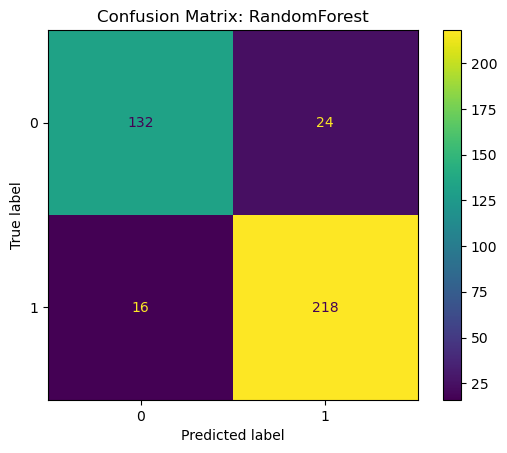

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       156
           1       0.90      0.93      0.92       234

    accuracy                           0.90       390
   macro avg       0.90      0.89      0.89       390
weighted avg       0.90      0.90      0.90       390


Evaluating ExtraTrees
Training Accuracy: 0.9903
Test Accuracy: 0.8872


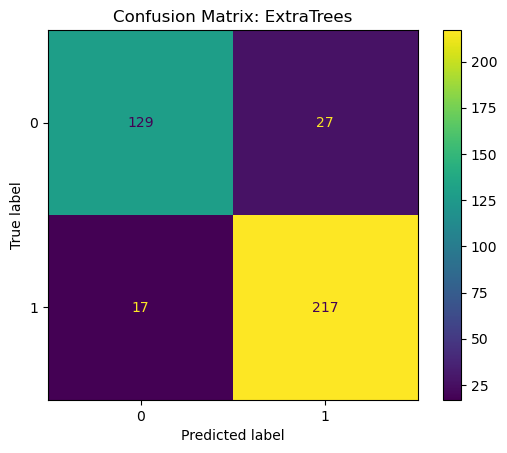

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       156
           1       0.89      0.93      0.91       234

    accuracy                           0.89       390
   macro avg       0.89      0.88      0.88       390
weighted avg       0.89      0.89      0.89       390


Evaluating LogisticRegression


c:\Users\iqmah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.5973
Test Accuracy: 0.6077


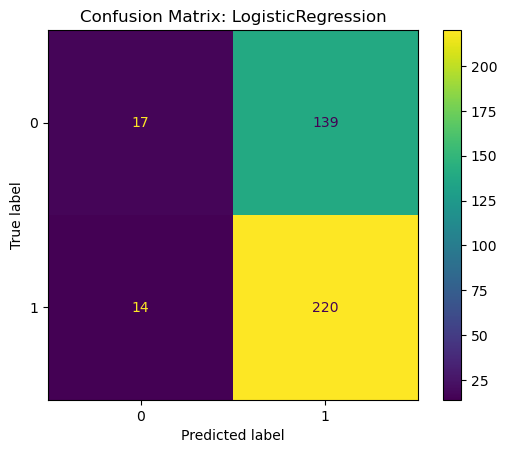

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.11      0.18       156
           1       0.61      0.94      0.74       234

    accuracy                           0.61       390
   macro avg       0.58      0.52      0.46       390
weighted avg       0.59      0.61      0.52       390


Evaluating XGBoost
Training Accuracy: 0.9645
Test Accuracy: 0.8769


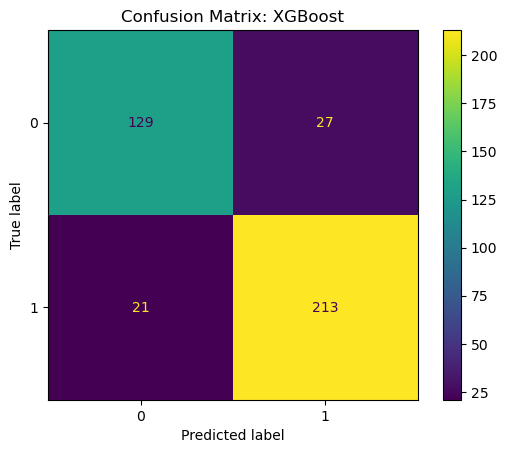

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       156
           1       0.89      0.91      0.90       234

    accuracy                           0.88       390
   macro avg       0.87      0.87      0.87       390
weighted avg       0.88      0.88      0.88       390


Evaluating MLPClassifier
Training Accuracy: 0.6325
Test Accuracy: 0.6256


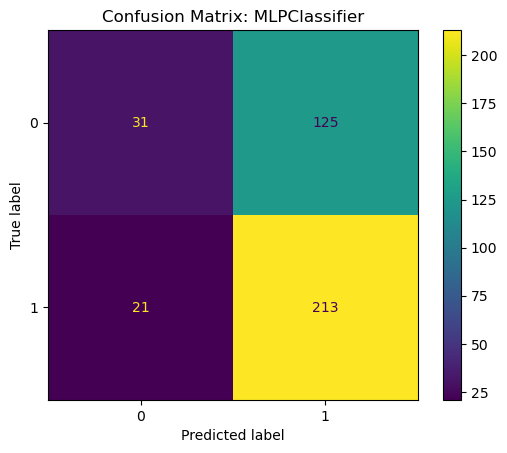

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.20      0.30       156
           1       0.63      0.91      0.74       234

    accuracy                           0.63       390
   macro avg       0.61      0.55      0.52       390
weighted avg       0.62      0.63      0.57       390


Evaluating LDA
Training Accuracy: 0.5983
Test Accuracy: 0.6026


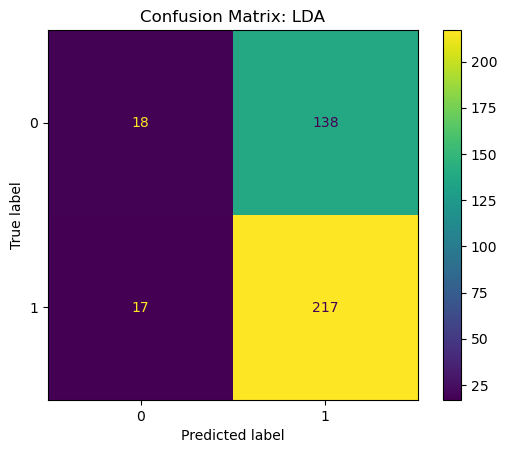

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.12      0.19       156
           1       0.61      0.93      0.74       234

    accuracy                           0.60       390
   macro avg       0.56      0.52      0.46       390
weighted avg       0.57      0.60      0.52       390


Evaluating LinearSVC
Training Accuracy: 0.6005
Test Accuracy: 0.6154


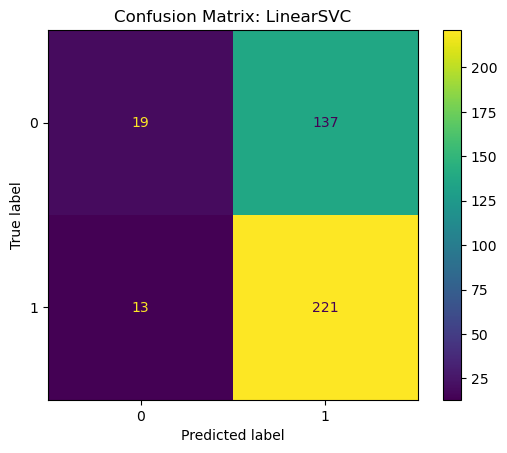

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.12      0.20       156
           1       0.62      0.94      0.75       234

    accuracy                           0.62       390
   macro avg       0.61      0.53      0.47       390
weighted avg       0.61      0.62      0.53       390


Evaluating LightGBM
Training Accuracy: 0.9057
Test Accuracy: 0.8590


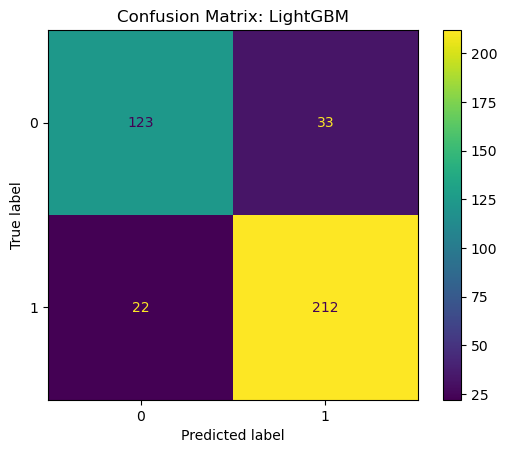

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       156
           1       0.87      0.91      0.89       234

    accuracy                           0.86       390
   macro avg       0.86      0.85      0.85       390
weighted avg       0.86      0.86      0.86       390


Evaluating HistGradientBoosting
Training Accuracy: 0.9018
Test Accuracy: 0.8436


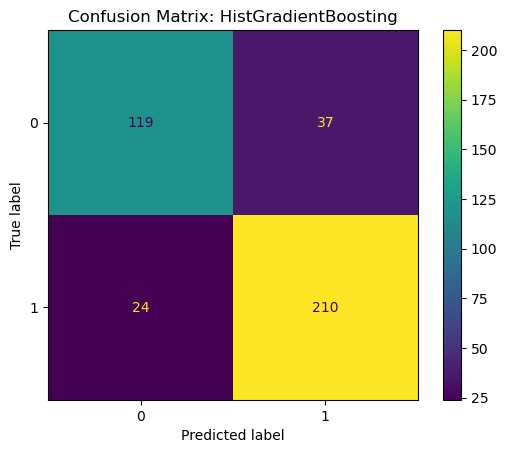

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.80       156
           1       0.85      0.90      0.87       234

    accuracy                           0.84       390
   macro avg       0.84      0.83      0.83       390
weighted avg       0.84      0.84      0.84       390


Evaluating RidgeClassifier
Training Accuracy: 0.5997
Test Accuracy: 0.6128


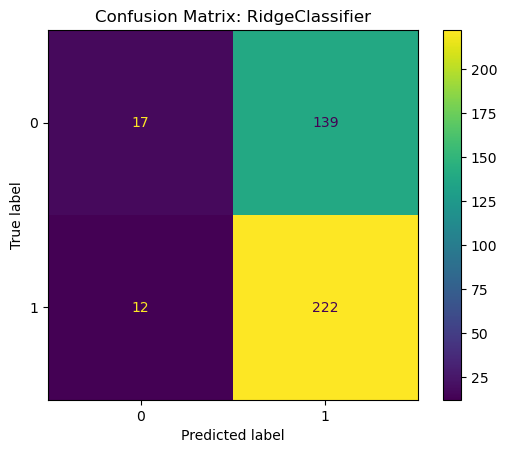

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.11      0.18       156
           1       0.61      0.95      0.75       234

    accuracy                           0.61       390
   macro avg       0.60      0.53      0.47       390
weighted avg       0.60      0.61      0.52       390


Average Metrics for Each Classifier:
             Classifier  Accuracy  Precision    Recall        F1
0          RandomForest  0.897436   0.896359  0.888889  0.892194
1            ExtraTrees  0.887179   0.886453  0.877137  0.881127
2    LogisticRegression  0.607692   0.580600  0.524573  0.461904
3               XGBoost  0.876923   0.873750  0.868590  0.870936
4         MLPClassifier  0.625641   0.613166  0.554487  0.521416
5                   LDA  0.602564   0.562777  0.521368  0.462662
6             LinearSVC  0.615385   0.605534  0.533120  0.474375
7              LightGBM  0.858974   0.856791  0.847222  0.851227
8  HistGradientBoosting  0.

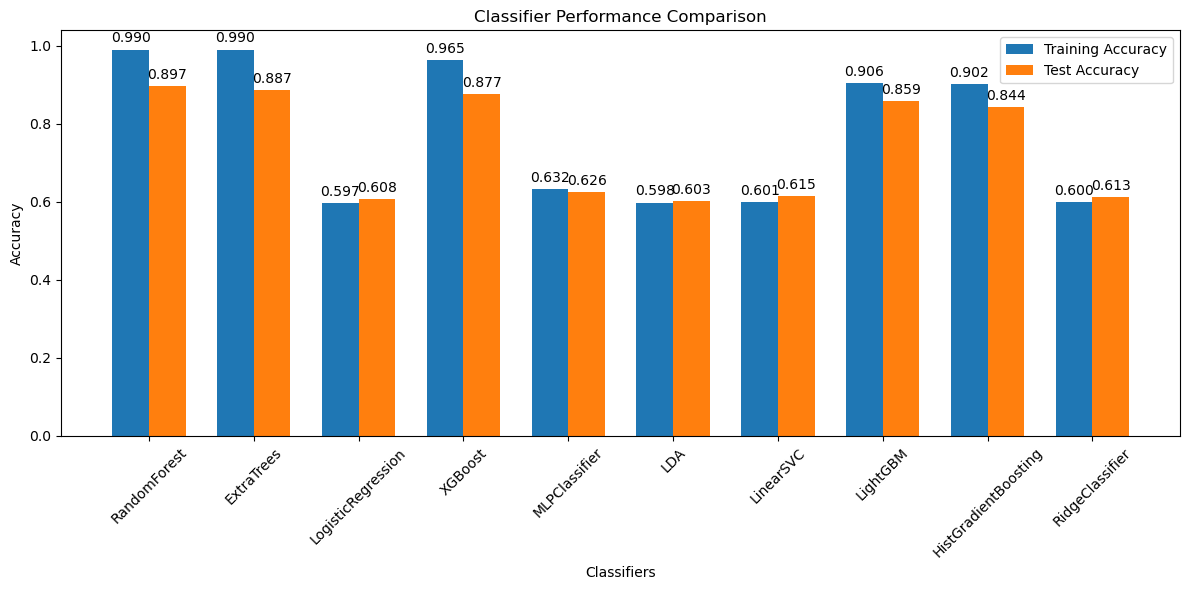

In [10]:
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier,
    HistGradientBoostingClassifier # إضافة الوحدات الجديدة
)
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    PassiveAggressiveClassifier, Perceptron
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier # إضافة الوحدة الجديدة
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# التحقق من تثبيت CatBoost
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("Warning: CatBoost not installed. Run '!pip install catboost'")

# Find the most frequent label for outlier_label
most_frequent_label = Counter(y_train).most_common(1)[0][0]



classifiers = {
    # --- المصنفات القوية (مفعلة) ---
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    # 'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42), # تم إيقافه (ضعيف)
    # 'GradientBoosting': GradientBoostingClassifier(n_estimators=10, random_state=42), # تم إيقافه (تم استبداله)
    # 'Bagging': BaggingClassifier(n_estimators=10, random_state=42), # تم إيقافه
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    #'SVM': SVC(random_state=42, probability=True),
    # 'KNN': KNeighborsClassifier(n_neighbors=5), # تم إيقافه (بطيء مع 5000 ميزة)
    # 'GaussianNB': GaussianNB(), # تم إيقافه (ضعيف مع البيانات المرتبطة)
    # 'DecisionTree': DecisionTreeClassifier(random_state=42), # تم إيقافه (ضعيف بمفرده)
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    'LDA': LinearDiscriminantAnalysis(),
    'LinearSVC': LinearSVC(random_state=42, max_iter=200),
    # 'QDA': QuadraticDiscriminantAnalysis(), # تم إيقافه (يفشل مع الأبعاد العالية)

    # --- المصنفات الجديدة المضافة (مفعلة) ---
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, random_state=42),
    'RidgeClassifier': RidgeClassifier(random_state=42),
}

# إضافة CatBoost إذا كان متاحاً
#if CATBOOST_AVAILABLE:
 #   classifiers['CatBoost'] = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=False, random_state=42)


results = {}

metrics_table = []
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    y_pred = clf.predict(X_test)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    metrics_table.append({
        'Classifier': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    results[name] = {'train_accuracy': train_acc, 'test_accuracy': test_acc}

metrics_df = pd.DataFrame(metrics_table)
print("\nAverage Metrics for Each Classifier:")
print(metrics_df)

# Plot comparison of all classifier results
names = list(results.keys())
train_accuracies = [results[name]['train_accuracy'] for name in names]
test_accuracies = [results[name]['test_accuracy'] for name in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy')

ax.set_xlabel('Classifiers')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
